# Calculation of the <font color="red"> average lightneass </font> of the images from samples after dirt pickup

In [ ]:
# Upload images.zip
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [ ]:
!unzip images.zip

Archive:  images.zip
   creating: images/
  inflating: images/3112.jpg         
  inflating: images/425.jpg          
  inflating: images/4302.jpg         
  inflating: images/4303.jpg         
  inflating: images/610.jpg          
  inflating: images/616.jpg          
  inflating: images/630.jpg          
  inflating: images/707.jpg          
  inflating: images/777.jpg          
  inflating: images/MP144.jpg        
  inflating: images/MP35.jpg         
  inflating: images/MT.jpg           
  inflating: images/NA65.jpg         
  inflating: images/SRT-30T.jpg      


In [ ]:
from PIL import Image
import os
import numpy as np
import pandas as pd

# Function to calculate average lightness of a single image
def calculate_lightness(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((400, 400))
    pixels = np.array(img)

    # Convert RGB to HSL and extract lightness
    def rgb_to_lightness(r, g, b):
        r, g, b = r/255.0, g/255.0, b/255.0
        max_val = max(r, g, b)
        min_val = min(r, g, b)
        return (max_val + min_val) / 2

    lightness_values = [
        rgb_to_lightness(r, g, b)
        for row in pixels for (r, g, b) in row
    ]

    return np.mean(lightness_values)

# Directory containing your images
image_folder = '/content/images/'
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Calculate average lightness for all images
lightness_list = []
for image_file in image_files:
    path = os.path.join(image_folder, image_file)
    avg_lightness = calculate_lightness(path)
    lightness_list.append((image_file, avg_lightness))

# Save to Excel
df = pd.DataFrame(lightness_list, columns=["file_name", "average_lightness"])
df.to_excel("average_lightness.xlsx", index=False)

# Estimation of Average Lightness for <font color=red>Delta L*</font> of 0.4 and 60

In [ ]:
# Upload DE_DL_AL.xlsx
from google.colab import files
uploaded = files.upload()

Saving DE_DL_AL.xlsx to DE_DL_AL.xlsx


Linear equation: y = -0.007 * x + 0.461
Equivalent average lightness for delta L* of 0.4 and 60 is 0.458 and 0.060, respectively


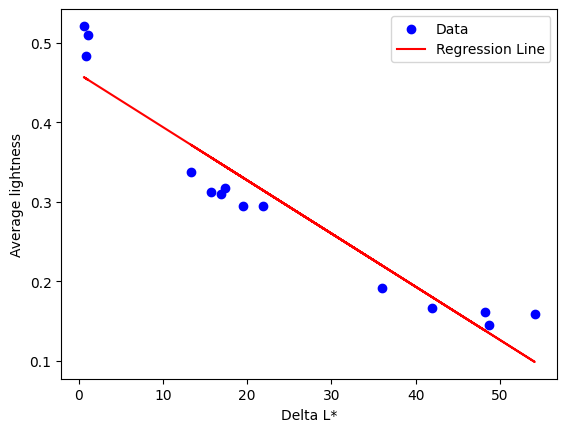

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


df=pd.read_excel("DE_DL_AL.xlsx")

y = df.iloc[:,4].values.reshape(-1, 1) # Average lightness
x = df.iloc[:,3].values.reshape(-1, 1) # Delta L*

model = LinearRegression()
model.fit(x, y)

slope = model.coef_[0][0]
intercept = model.intercept_[0]

print(f"Linear equation: y = {slope:.3f} * x + {intercept:.3f}")
print(f"Equivalent average lightness for delta L* of 0.4 and 60 is {(slope*0.4+intercept):.3f} and {(slope*60+intercept):.3f}, respectively")

import matplotlib.pyplot as plt

plt.scatter(x, y, color='blue', label='Data')
plt.plot(x, model.predict(x), color='red', label='Regression Line')
plt.xlabel('Delta L*')
plt.ylabel('Average lightness')
plt.legend()
plt.savefig("linear_relationship.png", format='png', dpi=600)
plt.show()

# Visualization of <font color=red> imported + fabricated </font> images

/tmp/ipython-input-788232295.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')
/tmp/ipython-input-788232295.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(pixels, mode='L')


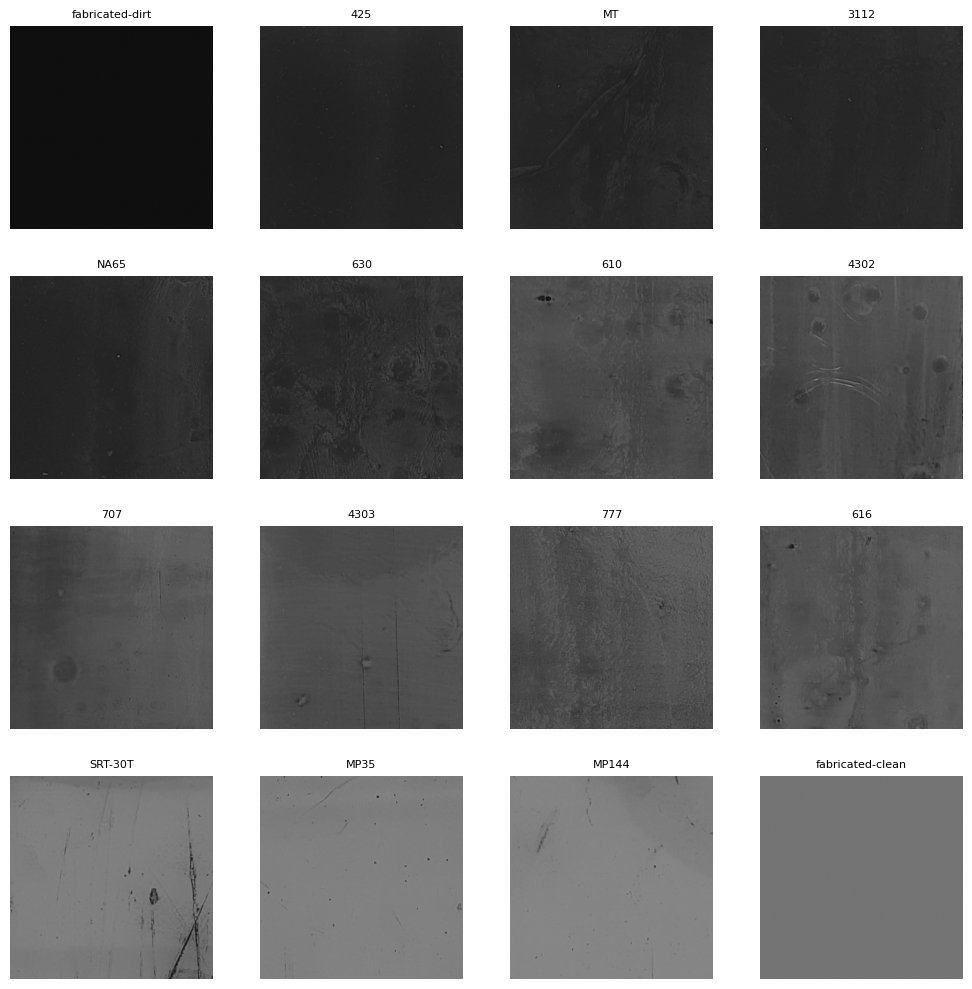

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

sorted_lightness = sorted(lightness_list, key=lambda x: x[1])

sorted_lightness.insert(0, ("fabricated-dirt.png", np.float64(0.06)))
sorted_lightness.insert(len(sorted_lightness), ("fabricated-clean.png", np.float64(0.458)))

# Fabricating ultra-dirt PNG
pixels = np.full((400, 400), int(0.06*255) , dtype=np.uint8)
image = Image.fromarray(pixels, mode='L')
image.save(image_folder+"fabricated-dirt.png", format="PNG")

# Fabricating ultra-clean PNG
pixels = np.full((400, 400), int(0.458*255) , dtype=np.uint8)
image = Image.fromarray(pixels, mode='L')
image.save(image_folder+"fabricated-clean.png", format="PNG")

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.tight_layout(pad=0.0)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through images and axes together
for ax, ithem in zip(axes, sorted_lightness):
    img_path = image_folder + ithem[0]
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')
    ax.set_title(ithem[0].replace(".jpg", "").replace(".png", ""), fontsize=8)
plt.savefig("final_sorted_images.png", format='png', dpi=600, bbox_inches='tight')
plt.show()